In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
%pip install s3fs tensorflow scikit-learn
import re

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 119.0 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2023.5.0
    Not uninstalling fsspec at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-6ed5bc64-0677-459b-8bb2-d97bf1c9b60d
    Can't uninstall 'fsspec'. No files were found to uninstall.
  Attempting uninstall: aiosignal
    Found existing installation: aiosignal 1.2.0
    Not uninstalling aiosignal at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-6ed5bc64-0677-459b-8bb2-d97bf1c9b60d
    Can't uninstall 'aiosignal'. No files were found to uninstall.
  Attempting uninstall: aiohappyeyeballs
    Found existing installation: aiohappyeyeballs 2.4.4
    Not uninstalling aiohappyeyeballs at /databricks/python3/lib/python3.12/site-packag

In [0]:
train_df = pd.read_csv("s3://humber-lfb-databricks-class-files/car-prices-s4e9/train.csv")
train_df.head(5)

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


In [0]:
train_df.shape

(188533, 13)

In [0]:
test_df = pd.read_csv( "s3://humber-lfb-databricks-class-files/car-prices-s4e9/test.csv")
test_df.head(5)

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
0,188533,Land,Rover LR2 Base,2015,98000,Gasoline,240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,White,Beige,None reported,Yes
1,188534,Land,Rover Defender SE,2020,9142,Hybrid,395.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,8-Speed A/T,Silver,Black,None reported,Yes
2,188535,Ford,Expedition Limited,2022,28121,Gasoline,3.5L V6 24V PDI DOHC Twin Turbo,10-Speed Automatic,White,Ebony,None reported,NaN
3,188536,Audi,A6 2.0T Sport,2016,61258,Gasoline,2.0 Liter TFSI,Automatic,Silician Yellow,Black,None reported,NaN
4,188537,Audi,A6 2.0T Premium Plus,2018,59000,Gasoline,252.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Gray,Black,None reported,Yes


In [0]:
test_df.shape

(125690, 12)

In [0]:
train_df.isna().sum()

id                  0
brand               0
model               0
model_year          0
milage              0
fuel_type        5083
engine              0
transmission        0
ext_col             0
int_col             0
accident         2452
clean_title     21419
price               0
dtype: int64

In [0]:
test_df.isna().sum()

id                  0
brand               0
model               0
model_year          0
milage              0
fuel_type        3383
engine              0
transmission        0
ext_col             0
int_col             0
accident         1632
clean_title     14239
dtype: int64

In [0]:
train_df['brand'].nunique()

57

In [0]:
print(train_df['model_year'].min())

print(train_df['model_year'].max())

1974
2024


In [0]:
train_df.fuel_type.value_counts()

fuel_type
Gasoline          165940
Hybrid              6832
E85 Flex Fuel       5406
Diesel              3955
–                    781
Plug-In Hybrid       521
not supported         15
Name: count, dtype: int64

In [0]:
#dropped rows with the '-' value, as it provides no useful information.
#Also remove rows labeled as 'not supported'.
train_df = train_df[~train_df['fuel_type'].isin(['–', 'not supported'])]

train_df.reset_index(drop=True, inplace=True)

In [0]:
train_df.fuel_type.value_counts()

fuel_type
Gasoline          165940
Hybrid              6832
E85 Flex Fuel       5406
Diesel              3955
Plug-In Hybrid       521
Name: count, dtype: int64

In [0]:
# Flex Fuel patterns
train_df.loc[
    (train_df['fuel_type'].isna()) &
    (train_df['engine'].str.contains("Flex", case=False, na=False)),
    'fuel_type'
] = 'E85 Flex Fuel'


# Hybrid / Electric patterns
train_df.loc[
    (train_df['fuel_type'].isna()) &
    (train_df['engine'].str.contains("Dual", case=False, na=False)),
    'fuel_type'
] = 'Hybrid'

train_df.loc[
    (train_df['fuel_type'].isna()) &
    (train_df['engine'].str.contains("Electric", case=False, na=False)),
    'fuel_type'
] = 'Hybrid'

train_df.loc[
    (train_df['fuel_type'].isna()) &
    (train_df['engine'].str.contains("Battery", case=False, na=False)),
    'fuel_type'
] = 'Hybrid'

train_df.loc[
    (train_df['fuel_type'].isna()) &
    (train_df['engine'].str.contains("kW", case=False, na=False)),
    'fuel_type'
] = 'Hybrid'

train_df.loc[
    (train_df['fuel_type'].isna()) &
    (train_df['engine'].str.contains("AH", case=False, na=False)),
    'fuel_type'
] = 'Hybrid'

train_df.loc[
    (train_df['fuel_type'].isna()) &
    (train_df['brand'].str.contains("Tesla", case=False, na=False)),
    'fuel_type'
] = 'Hybrid'

train_df.loc[
    (train_df['fuel_type'].isna()) &
    (train_df['model'].str.contains("Hybrid", case=False, na=False)),
    'fuel_type'
] = 'Hybrid'


# Gasoline patterns
train_df.loc[
    (train_df['fuel_type'].isna()) &
    (train_df['engine'].str.contains("GDI", case=False, na=False)),
    'fuel_type'
] = 'Gasoline'

train_df.loc[
    (train_df['fuel_type'].isna()) &
    (train_df['engine'].str.contains("PDI", case=False, na=False)),
    'fuel_type'
] = 'Gasoline'

train_df.loc[
    (train_df['fuel_type'].isna()) &
    (train_df['engine'].str.contains("OHV", case=False, na=False)),
    'fuel_type'
] = 'Gasoline'

train_df.loc[
    (train_df['fuel_type'].isna()) &
    (train_df['engine'].str.contains("MPFI", case=False, na=False)),
    'fuel_type'
] = 'Gasoline'

train_df.loc[
    (train_df['fuel_type'].isna()) &
    (train_df['engine'].str.contains("TFSI", case=False, na=False)),
    'fuel_type'
] = 'Gasoline'

train_df.loc[
    (train_df['fuel_type'].isna()) &
    (train_df['engine'].str.contains("DOHC", case=False, na=False)),
    'fuel_type'
] = 'Gasoline'

train_df.loc[
    (train_df['fuel_type'].isna()) &
    (train_df['engine'].str.contains("Gasoline", case=False, na=False)),
    'fuel_type'
] = 'Gasoline'

train_df.loc[
    (train_df['fuel_type'].isna()) &
    (train_df['model_year'] < 2020),
    'fuel_type'
] = 'Gasoline'


# Diesel patterns
train_df.loc[
    (train_df['fuel_type'].isna()) &
    (train_df['engine'].str.contains("Diesel", case=False, na=False)),
    'fuel_type'
] = 'Diesel'


In [0]:
train_df['fuel_type'] = train_df['fuel_type'].fillna('Unknown')

In [0]:
print("Missing clean_title:", train_df['clean_title'].isna().sum())
print("Missing accident:", train_df['accident'].isna().sum())



Missing clean_title: 21393
Missing accident: 2435


In [0]:
# Accident reported → NOT a clean title
train_df.loc[
    (train_df['clean_title'].isna()) &
    (train_df['accident'] == 'At least 1 accident or damage reported'),
    'clean_title'
] = 'No'


# No accident reported → clean title
train_df.loc[
    (train_df['clean_title'].isna()) &
    (train_df['accident'] == 'None reported'),
    'clean_title'
] = 'Yes'


In [0]:

train_df['clean_title'] = train_df['clean_title'].fillna('Unknown')
train_df['accident'] = train_df['accident'].fillna('None reported')


In [0]:
train_df[['clean_title', 'accident']].isna().sum()


clean_title    0
accident       0
dtype: int64

In [0]:
# -------------------------------
# 1. Handle missing fuel_type
# -------------------------------

# Flex Fuel
test_df.loc[
    (test_df['fuel_type'].isna()) &
    (test_df['engine'].str.contains("Flex", case=False, na=False)),
    'fuel_type'
] = 'E85 Flex Fuel'

# Hybrid / Electric
test_df.loc[
    (test_df['fuel_type'].isna()) &
    (test_df['engine'].str.contains("Dual|Electric|Battery|kW|AH", case=False, na=False)),
    'fuel_type'
] = 'Hybrid'

test_df.loc[
    (test_df['fuel_type'].isna()) &
    (test_df['brand'].str.contains("Tesla", case=False, na=False)),
    'fuel_type'
] = 'Hybrid'

test_df.loc[
    (test_df['fuel_type'].isna()) &
    (test_df['model'].str.contains("Hybrid", case=False, na=False)),
    'fuel_type'
] = 'Hybrid'

# Diesel
test_df.loc[
    (test_df['fuel_type'].isna()) &
    (test_df['engine'].str.contains("Diesel", case=False, na=False)),
    'fuel_type'
] = 'Diesel'

# Gasoline (engine patterns + older cars)
test_df.loc[
    (test_df['fuel_type'].isna()) &
    (test_df['engine'].str.contains(
        "GDI|PDI|OHV|MPFI|TFSI|DOHC|Gasoline",
        case=False,
        na=False
    )),
    'fuel_type'
] = 'Gasoline'

test_df.loc[
    (test_df['fuel_type'].isna()) &
    (test_df['model_year'] < 2020),
    'fuel_type'
] = 'Gasoline'

# Final fallback
test_df['fuel_type'] = test_df['fuel_type'].fillna('Unknown')


# -------------------------------
# 2. Handle missing clean_title using accident
# -------------------------------

# Accident reported → NOT clean title
test_df.loc[
    (test_df['clean_title'].isna()) &
    (test_df['accident'] == 'At least 1 accident or damage reported'),
    'clean_title'
] = 'No'

# No accident reported → clean title
test_df.loc[
    (test_df['clean_title'].isna()) &
    (test_df['accident'] == 'None reported'),
    'clean_title'
] = 'Yes'

# Final fallback
test_df['clean_title'] = test_df['clean_title'].fillna('Unknown')


# -------------------------------
# 3. Handle missing accident
# -------------------------------

test_df['accident'] = test_df['accident'].fillna('None reported')


# -------------------------------
# 4. Final validation
# -------------------------------

test_df[['fuel_type', 'clean_title', 'accident']].isna().sum()


fuel_type      0
clean_title    0
accident       0
dtype: int64

Missing values were handled using a rule-based, domain-driven approach to preserve data integrity and avoid arbitrary imputation. For the fuel_type variable, missing entries were inferred using engine specifications, brand information, model naming patterns, and vehicle year. This allowed realistic classification into categories such as Gasoline, Diesel, Hybrid, and Flex Fuel, with remaining unknown cases labeled as “Unknown."

For the clean_title variable, missing values were imputed using information from the accident column. Vehicles with reported accidents were classified as not having a clean title, while vehicles with no reported accidents were marked as having a clean title. Any unresolved cases were assigned an “Unknown” category.

For the accident variable, missing values were filled with “None reported” to indicate the absence of recorded accident information. This ensured all categorical variables were complete and suitable for encoding and modeling while maintaining logical consistency across related features.

In [0]:

train_df.columns = [s.strip().replace(' ','_') for s in train_df.columns]

In [0]:
test_df.columns = [s.strip().replace(' ','_') for s in test_df.columns]

In [0]:
train_df.columns

Index(['id', 'brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

In [0]:
test_df.columns

Index(['id', 'brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title'],
      dtype='object')

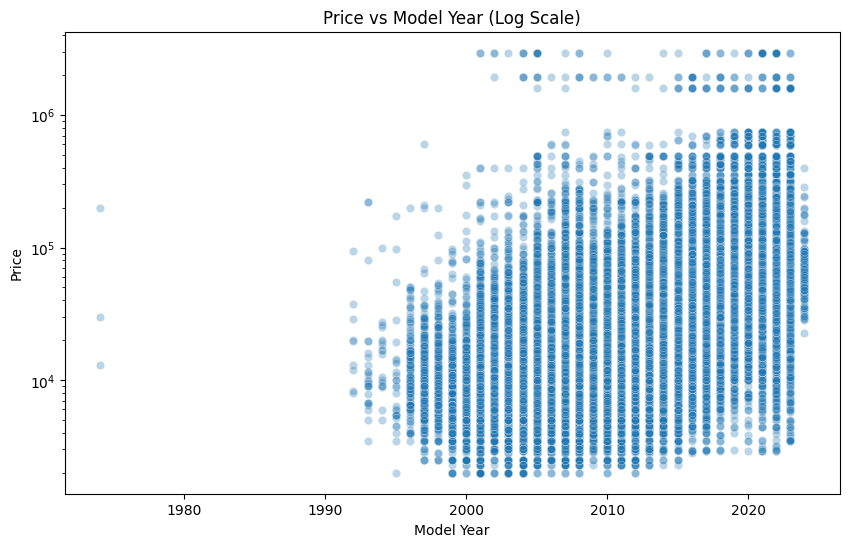

In [0]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=train_df['model_year'],
    y=train_df['price'],
    alpha=0.3
)
plt.yscale('log')
plt.xlabel('Model Year')
plt.ylabel('Price')
plt.title('Price vs Model Year (Log Scale)')
plt.show()


Insight: Newer vehicles generally command higher prices.

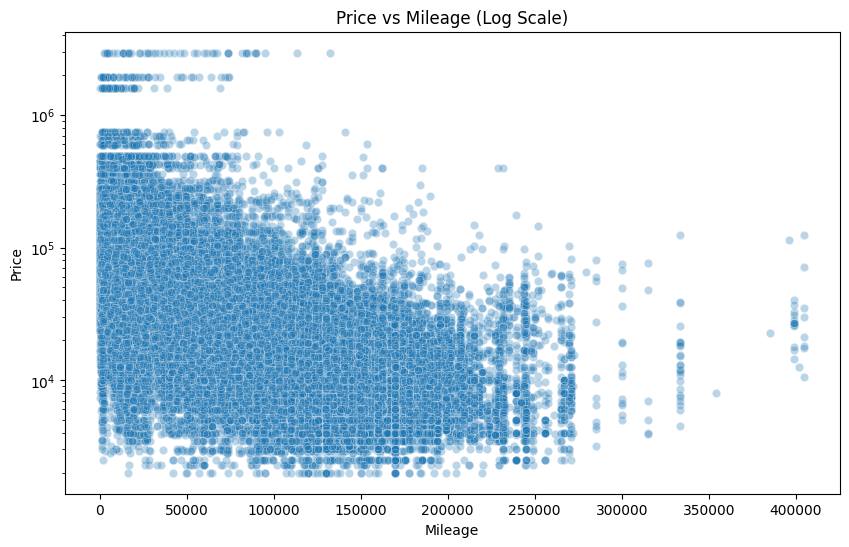

In [0]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=train_df['milage'],
    y=train_df['price'],
    alpha=0.3
)
plt.yscale('log')
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.title('Price vs Mileage (Log Scale)')
plt.show()


Insight: Higher mileage is associated with lower vehicle prices.

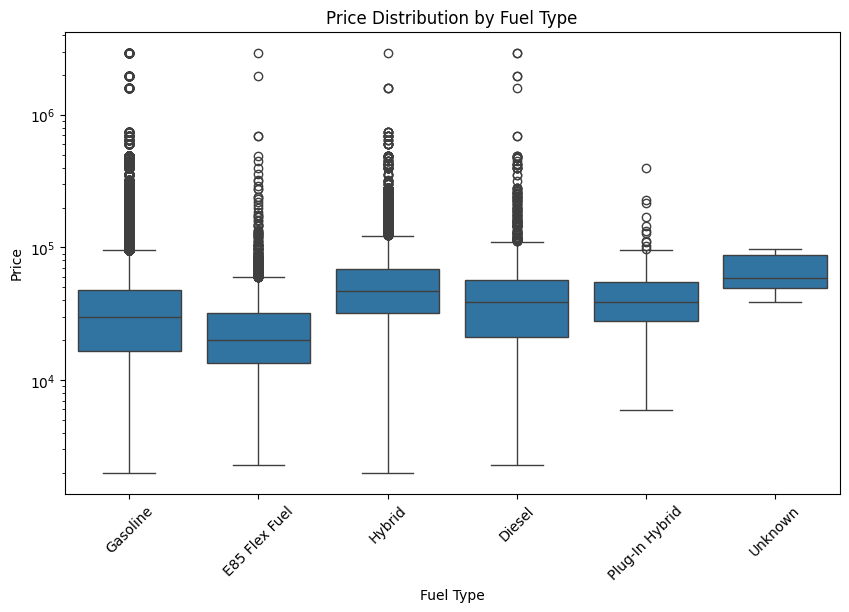

In [0]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x='fuel_type',
    y='price',
    data=train_df
)
plt.yscale('log')
plt.xticks(rotation=45)
plt.xlabel('Fuel Type')
plt.ylabel('Price')
plt.title('Price Distribution by Fuel Type')
plt.show()


The boxplot shows clear price separation across different fuel types. Hybrid and plug-in hybrid vehicles exhibit higher median prices, reflecting their newer technology and market premium. Gasoline vehicles display the widest price range, indicating significant variability across models. Diesel vehicles also tend to be priced higher than gasoline vehicles, while flex-fuel vehicles show comparatively lower prices. These patterns confirm fuel type as an important predictor of used car prices.

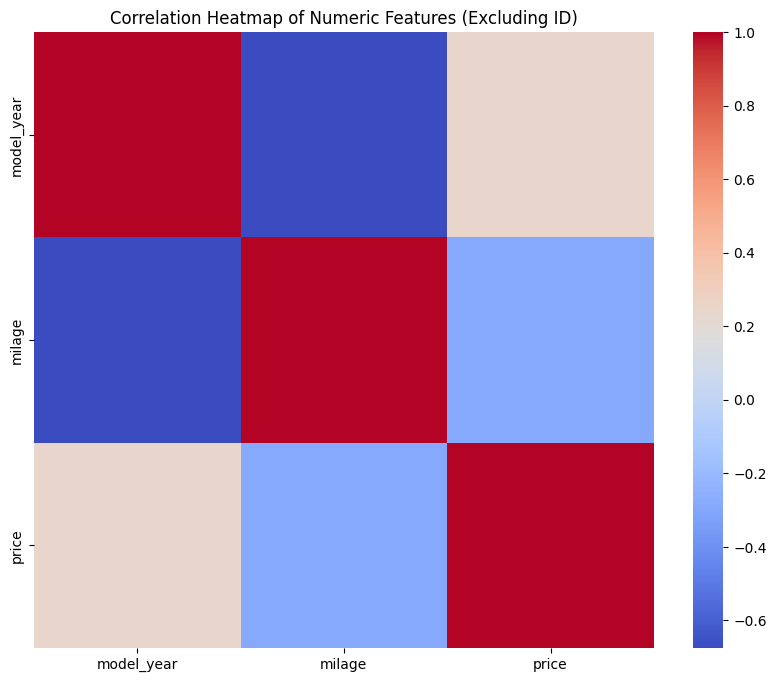

In [0]:
numeric_cols = (
    train_df
    .select_dtypes(include=['int64', 'float64'])
    .drop(columns=['id'], errors='ignore')
)

plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_cols.corr(),
    cmap='coolwarm',
    annot=False
)
plt.title('Correlation Heatmap of Numeric Features (Excluding ID)')
plt.show()



In [0]:
# Outcome
y_train = train_df["price"]

# Predictors (drop id and price)
X_train = train_df.drop(columns=["id", "price"])


In [0]:
X_test = test_df.drop(columns=["id"])

In [0]:

# Combine train and test to ensure same encoded columns
combined_df = pd.concat([X_train, X_test], axis=0)

combined_df = pd.get_dummies(combined_df, drop_first=True)

# Split back into train and test
X_train = combined_df.iloc[:len(X_train)]
X_test  = combined_df.iloc[len(X_train):]


In [0]:
X_train.head()


,model_year,milage,brand_Alfa,brand_Aston,brand_Audi,brand_BMW,brand_Bentley,brand_Bugatti,brand_Buick,brand_Cadillac,brand_Chevrolet,brand_Chrysler,brand_Dodge,brand_FIAT,brand_Ferrari,brand_Ford,brand_GMC,brand_Genesis,brand_Honda,brand_Hummer,brand_Hyundai,brand_INFINITI,brand_Jaguar,brand_Jeep,brand_Karma,brand_Kia,brand_Lamborghini,brand_Land,brand_Lexus,brand_Lincoln,brand_Lotus,brand_Lucid,brand_MINI,brand_Maserati,brand_Maybach,brand_Mazda,brand_McLaren,brand_Mercedes-Benz,brand_Mercury,brand_Mitsubishi,...,int_col_Red / Black,int_col_Red/Black,int_col_Rhapsody Blue,int_col_Rioja Red,int_col_Roast,int_col_Rock Gray,int_col_Saddle Brown,int_col_Sahara Tan,int_col_Saiga Beige,int_col_Sakhir Orange,int_col_Sakhir Orange/Black,int_col_Sand Beige,int_col_Sandstone,int_col_Sarder Brown,int_col_Satin Black,int_col_Shale,int_col_Shara Beige,int_col_Silk Beige/Black,int_col_Silk Beige/Espresso Brown,int_col_Silver,int_col_Slate,int_col_Sport,int_col_Tan,int_col_Tan/Ebony,int_col_Tan/Ebony/Ebony,int_col_Tension,int_col_Titan Black,int_col_Titan Black / Quarzit,int_col_Tupelo,int_col_Very Light Cashmere,int_col_WHITE,int_col_Walnut,int_col_Whisper Beige,int_col_White,int_col_White / Brown,int_col_Yellow,int_col_–,accident_None reported,clean_title_Unknown,clean_title_Yes
0,2007,213000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
1,2002,143250,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,2002,136731,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
3,2017,19500,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
4,2021,7388,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True


In [0]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


2026-02-09 00:35:49.809692: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-09 00:35:49.909672: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-09 00:35:49.942673: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770597349.973812    1739 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770597349.981357    1739 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770597350.026302    1739 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [0]:
model = Sequential()

model.add(Dense(32, activation="relu", input_dim=X_train.shape[1]))
model.add(Dense(16, activation="relu"))
model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


/databricks/python/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-02-09 00:36:04.091758: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [0]:
X_train = X_train.astype("float32")
X_test  = X_test.astype("float32")
y_train = y_train.astype("float32")




In [0]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


2026-02-09 00:37:04.839553: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 2166326136 exceeds 10% of free system memory.


Epoch 1/10
2329/2347 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7103432704.0000 - mae: 31308.5234

2026-02-09 00:37:36.290474: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 541592352 exceeds 10% of free system memory.


2347/2347 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 7094448128.0000 - mae: 31262.5879 - val_loss: 5696519680.0000 - val_mae: 24012.8730
Epoch 2/10
2332/2347 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5624132096.0000 - mae: 22607.6367

2347/2347 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 5623414784.0000 - mae: 22605.6484 - val_loss: 5680163840.0000 - val_mae: 21706.3418
Epoch 3/10
2344/2347 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4909117952.0000 - mae: 21899.9199

2347/2347 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 4910133248.0000 - mae: 21900.5156 - val_loss: 5675500032.0000 - val_mae: 22115.7480
Epoch 4/10
2347/2347 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 5123174400.0000 - mae: 21965.5801 - val_loss: 5680214016.0000 - val_mae: 23051.4473
Epoch 5/10
2342/2347 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5000931840.0000 - mae: 21909.6660

2347/2347 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 5002211328.0000 - mae: 21910.4277 - val_loss: 5672591872.0000 - val_mae: 22393.5391
Epoch 6/10
2347/2347 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 5321281024.0000 - mae: 22138.6426 - val_loss: 5673297920.0000 - val_mae: 22612.1641
Epoch 7/10
2338/2347 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5198298624.0000 - mae: 22024.4609

2347/2347 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 5199599104.0000 - mae: 22025.3008 - val_loss: 5672507392.0000 - val_mae: 21921.8828
Epoch 8/10
2347/2347 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 5866092544.0000 - mae: 22598.9707 - val_loss: 5690762752.0000 - val_mae: 23963.9453
Epoch 9/10
2347/2347 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 5761701376.0000 - mae: 22215.6230 - val_loss: 5684091392.0000 - val_mae: 22319.1016
Epoch 10/10
2347/2347 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 5993473024.0000 - mae: 22546.9688 - val_loss: 5700909056.0000 - val_mae: 21761.0605


Uploading artifacts:   0%|          | 0/2 [00:00<?, ?it/s]

In [0]:
test_predictions = model.predict(X_test)


2026-02-09 00:40:03.521642: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1812952560 exceeds 10% of free system memory.


3928/3928 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


In [0]:
# Add predictions to test dataframe
test_df["predicted_price"] = test_predictions.flatten()

# View sample results
test_df[["id", "predicted_price"]].head()


,id,predicted_price
0,188533,20161.210938
1,188534,79902.015625
2,188535,56219.394531
3,188536,34500.976562
4,188537,35320.363281


In [0]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Predict on training data
train_predictions = model.predict(X_train)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
print("Neural Network RMSE:", rmse)



2026-02-09 00:43:05.629962: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 2707918488 exceeds 10% of free system memory.


5867/5867 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
Neural Network RMSE: 74538.84678474707


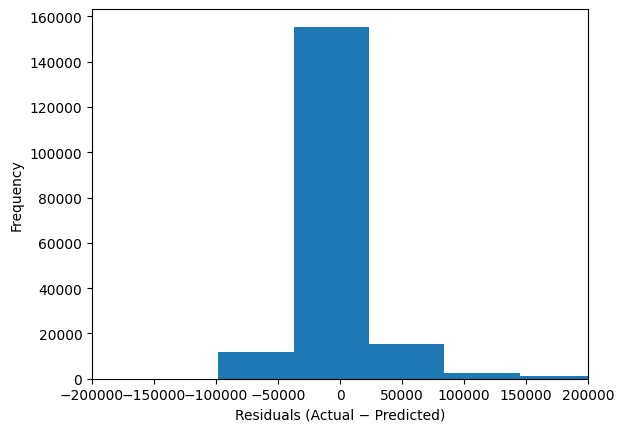

In [0]:

residuals = y_train - train_predictions.flatten()

plt.figure()
plt.hist(residuals, bins=50)

# Zoom into central error region
plt.xlim(-200000, 200000)

plt.xlabel("Residuals (Actual − Predicted)")
plt.ylabel("Frequency")
plt.show()



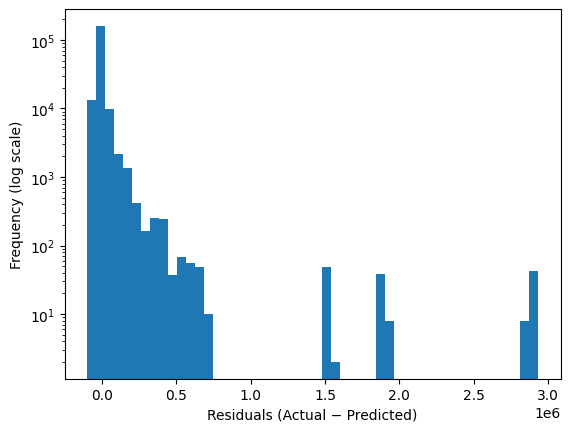

In [0]:
plt.figure()
plt.hist(residuals, bins=50)
plt.yscale("log")
plt.xlabel("Residuals (Actual − Predicted)")
plt.ylabel("Frequency (log scale)")
plt.show()


In [0]:
# Separate target
y_train = train_df["price"]

# Drop id and target from features
X_train = train_df.drop(columns=["id", "price"])
X_test  = test_df.drop(columns=["id"])


In [0]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

# Apply Label Encoding column by column
for col in cat_cols:
    le = LabelEncoder()
    
    # Fit on combined data to keep train/test consistent
    combined = pd.concat([X_train[col], X_test[col]], axis=0)
    le.fit(combined.astype(str))
    
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str))


In [0]:
X_train.dtypes.head()


brand         int64
model         int64
model_year    int64
milage        int64
fuel_type     int64
dtype: object

In [0]:
import numpy as np

# Log-transform target 
y_train_log = np.log1p(y_train)


In [0]:
from sklearn.linear_model import LinearRegression

# Initialize Linear Regression
lr = LinearRegression()

# Fit on log-transformed target
lr.fit(X_train, y_train_log)


LinearRegression()

In [0]:
# Predict log(price)
train_preds_log = lr.predict(X_train)

# Convert back to original price scale
train_preds = np.expm1(train_preds_log)


In [0]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Calculate RMSE
lr_rmse = np.sqrt(mean_squared_error(y_train, train_preds))

print("Linear Regression RMSE:", lr_rmse)
log_rmse = np.sqrt(mean_squared_error(y_train_log, train_preds_log))
print("Log RMSE for Linear Regression:", log_rmse)


Linear Regression RMSE: 74699.29619283743
Log RMSE for Linear Regression: 0.5284926798048163


In [0]:
from sklearn.metrics import mean_squared_error
import numpy as np

log_rmse = np.sqrt(mean_squared_error(y_train_log, train_preds_log))
print("Log RMSE for Linear Regression:", log_rmse)


Log RMSE for Linear Regression: 0.5284926798048163


In [0]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=50,       # fewer trees
    max_depth=10,          # shallower trees
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)


In [0]:
rf.fit(X_train, y_train_log)


RandomForestRegressor(max_depth=10, min_samples_leaf=10, min_samples_split=20,
                      n_estimators=50, n_jobs=-1, random_state=42)

In [0]:
# Predict log(price)
rf_train_preds_log = rf.predict(X_train)


In [0]:
# Convert predictions back to original price scale
rf_train_preds = np.expm1(rf_train_preds_log)


In [0]:
from sklearn.metrics import mean_squared_error
import numpy as np

rf_rmse = np.sqrt(mean_squared_error(y_train, rf_train_preds))
print("Random Forest RMSE:", rf_rmse)


Random Forest RMSE: 73223.15228273785


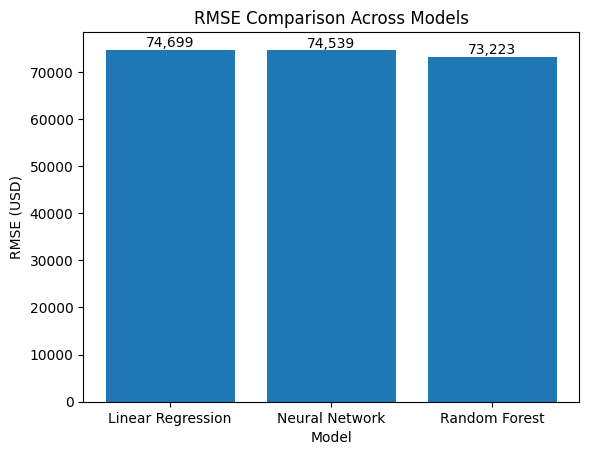

In [0]:
import matplotlib.pyplot as plt

models = ["Linear Regression", "Neural Network", "Random Forest"]
rmse_values = [lr_rmse, rmse, rf_rmse]

plt.figure()
bars = plt.bar(models, rmse_values)
plt.ylabel("RMSE (USD)")
plt.xlabel("Model")
plt.title("RMSE Comparison Across Models")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        va="bottom"
    )

plt.show()





In [0]:
num_features = X_train.shape[1]

print(f"Number of predictors used in the model: {num_features}")


Number of predictors used in the model: 11


In [0]:
import pandas as pd

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

# Sort and select top 5
top_5_features = feature_importance.sort_values(
    by="Importance", ascending=False
).head(5)

top_5_features


,Feature,Importance
3,milage,0.697057
2,model_year,0.187608
5,engine,0.085833
1,model,0.012663
0,brand,0.008259


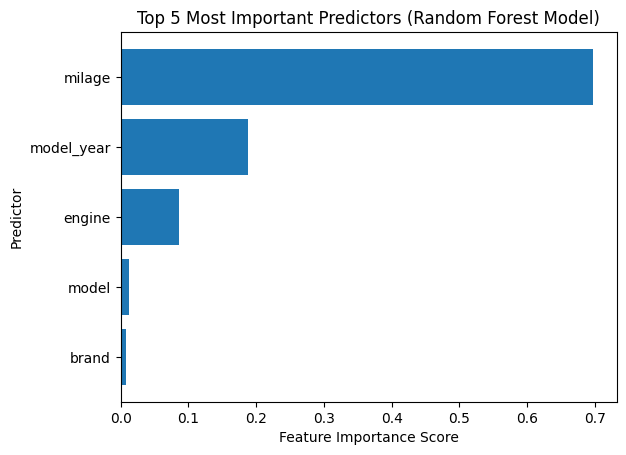

In [0]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(
    top_5_features["Feature"],
    top_5_features["Importance"]
)
plt.xlabel("Feature Importance Score")
plt.ylabel("Predictor")
plt.title("Top 5 Most Important Predictors (Random Forest Model)")
plt.gca().invert_yaxis()  # most important feature on top
plt.show()


In [0]:
import pandas as pd

# Combine predictors and target
corr_df = X_train.copy()
corr_df["price"] = y_train


In [0]:
correlation_matrix = corr_df.corr()


In [0]:
price_correlation = correlation_matrix[["price"]].sort_values(
    by="price", ascending=False
)

price_correlation


,price
price,1.000000
model_year,0.236210
engine,0.211557
accident,0.125403
int_col,0.035705
fuel_type,0.034267
brand,0.017599
transmission,0.014292
clean_title,-0.005411
ext_col,-0.017303


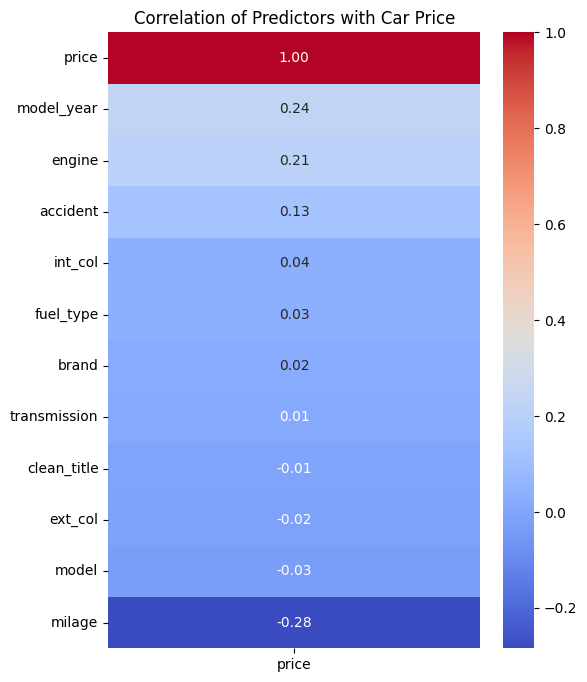

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 8))
sns.heatmap(
    price_correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    cbar=True
)

plt.title("Correlation of Predictors with Car Price")
plt.show()


The top three predictors are consistent across both correlation analysis and Random Forest feature importance, indicating strong and stable relationships with car price. However, differences in the remaining predictors arise because correlation measures only linear associations, while Random Forest feature importance captures non-linear effects and feature interactions. As a result, some variables contribute meaningfully to prediction accuracy despite having weaker linear correlations